# NovaPay - Fraudulent Transaction Detection for Digital Money Transfer

## Day 6: Advanced Modeling & Imbalance Handling

This notebook extends the Day 5 baseline work by training advanced tree-based models and testing imbalance-handling strategies on fraud transaction data. The project aim remains the same: identify fraudulent digital money-transfer transactions while keeping the evaluation realistic for future production use.

The workflow is deliberately reproducible: data is sorted by time, the final test period is kept untouched, all preprocessing is fitted only on training data inside pipelines, and results are saved to the Day 6 reports, artifacts, and models folders.


In [1]:
%pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42

# Imbalance handling packages
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline

    IMBLEARN_AVAILABLE = True
    print("imbalanced-learn is installed. SMOTE and undersampling will be used.")
except ImportError as exc:
    IMBLEARN_AVAILABLE = False
    SMOTE = None
    RandomUnderSampler = None
    ImbPipeline = None
    print("imbalanced-learn is not installed. SMOTE and undersampling experiments will be skipped.")
    print(f"Details: {exc}")
    print("Install with: pip install imbalanced-learn")

# XGBoost package
try:
    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True
    print("XGBoost is installed and will be used.")
except ImportError as exc:
    XGBOOST_AVAILABLE = False
    XGBClassifier = None
    print("XGBoost is not installed. XGBoost experiments will be skipped.")
    print(f"Details: {exc}")
    print("Install with: pip install xgboost")

# LightGBM package
try:
    from lightgbm import LGBMClassifier

    LIGHTGBM_AVAILABLE = True
    print("LightGBM is installed and will be used.")
except ImportError as exc:
    LIGHTGBM_AVAILABLE = False
    LGBMClassifier = None
    print("LightGBM is not installed. LightGBM experiments will be skipped.")
    print(f"Details: {exc}")
    print("Install with: pip install lightgbm")

print("\nPackage availability:")
print("IMBLEARN_AVAILABLE:", IMBLEARN_AVAILABLE)
print("XGBOOST_AVAILABLE :", XGBOOST_AVAILABLE)
print("LIGHTGBM_AVAILABLE:", LIGHTGBM_AVAILABLE)


imbalanced-learn is installed. SMOTE and undersampling will be used.
XGBoost is installed and will be used.
LightGBM is installed and will be used.

Package availability:
IMBLEARN_AVAILABLE: True
XGBOOST_AVAILABLE : True
LIGHTGBM_AVAILABLE: True


## 2. Create Output Folders

All Day 6 outputs are written to dedicated folders so results can be reviewed later without searching through the notebook. Figures, experiment logs, threshold analysis, summary files, and saved models are separated by purpose. This also makes the work reproducible because every generated file has a predictable location.


In [3]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "outputs":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "feature_engineered_transactions.csv"
BASELINE_METRICS_PATH = PROJECT_ROOT / "reports" / "artifacts" / "day5" / "baseline_model_metrics.csv"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "day6"
ARTIFACTS_DIR = PROJECT_ROOT / "reports" / "artifacts" / "day6"
MODELS_DIR = PROJECT_ROOT / "models" / "day6"

for folder in [FIGURES_DIR, ARTIFACTS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures folder:", FIGURES_DIR)
print("Artifacts folder:", ARTIFACTS_DIR)
print("Models folder:", MODELS_DIR)


Project root: C:\Users\sadeq
Figures folder: C:\Users\sadeq\reports\figures\day6
Artifacts folder: C:\Users\sadeq\reports\artifacts\day6
Models folder: C:\Users\sadeq\models\day6


## 3. Load Data

The notebook uses the feature-engineered transaction dataset created earlier in the project. Loading the prepared data here keeps Day 6 focused on advanced modelling rather than repeating feature engineering.

The fraud distribution is displayed immediately because the size of the minority class determines how carefully recall, precision, and imbalance methods need to be interpreted.


In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Expected feature-engineered dataset was not found at {DATA_PATH}. "
        "Run the Day 4 feature engineering notebook first, or place the CSV at this path."
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nFraud distribution:")
display(df["is_fraud"].value_counts(dropna=False).rename_axis("is_fraud").to_frame("count"))
display((df["is_fraud"].value_counts(normalize=True, dropna=False) * 100).round(3).rename("percent").to_frame())

print("\nTimestamp range:")
print("Minimum:", df["timestamp"].min())
print("Maximum:", df["timestamp"].max())

missing_summary = (
    df.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame("missing_values")
)
missing_summary["missing_percent"] = (missing_summary["missing_values"] / len(df) * 100).round(3)
display(missing_summary.head(30))


Shape: (10940, 52)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,customer_recency_days,device_transaction_count,device_avg_trust_score,device_trust_band,high_velocity_1h_flag,high_velocity_24h_flag,any_velocity_risk_flag,high_ip_risk_flag,low_device_trust_flag,chargeback_group
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,...,16.756991,7,0.500571,Medium,0,0,0,0,0,No Chargeback
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,59.824016,3,0.575000,Medium,0,0,0,0,0,No Chargeback
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.000000,22,0.932182,Very High,0,0,0,0,0,No Chargeback
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,74.644699,21,0.543857,Medium,0,0,0,0,0,No Chargeback
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,37.192859,34,0.889455,Very High,0,0,0,0,0,No Chargeback



Fraud distribution:


,count
is_fraud,
0,9951
1,989


,percent
is_fraud,
0,90.96
1,9.04



Timestamp range:
Minimum: 2022-10-03 18:40:59.468549+00:00
Maximum: 2025-12-16 00:13:41.468549+00:00


,missing_values,missing_percent
amount_usd,290,2.651
fee,290,2.651
ip_address,290,2.651
device_trust_score,290,2.651
amount_to_customer_avg,290,2.651
device_trust_band,290,2.651
customer_avg_amount,2,0.018
customer_max_amount,2,0.018
device_avg_trust_score,2,0.018


## 4. Timestamp Handling and Time-Based Split

A time-based split is used instead of a random split because fraud models are normally trained on past transactions and then applied to future transactions. Random splitting can leak future patterns into training and make performance look more stable than it would be in production.

The final 20% of transactions by timestamp becomes the untouched test set. SMOTE, undersampling, preprocessing, and model fitting are applied only through training pipelines so the test period remains a fair simulation of unseen future data.


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
if df["timestamp"].isna().any():
    missing_timestamps = int(df["timestamp"].isna().sum())
    raise ValueError(f"{missing_timestamps} rows have invalid timestamps after conversion.")

df = df.sort_values("timestamp").reset_index(drop=True)

split_idx = int(len(df) * 0.80)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

def describe_split(name, split_df):
    print(f"{name} rows: {len(split_df):,}")
    print(f"{name} fraud rate: {split_df['is_fraud'].mean():.4%}")
    print(f"{name} timestamp range: {split_df['timestamp'].min()} to {split_df['timestamp'].max()}")
    print()

describe_split("Train", train_df)
describe_split("Test", test_df)


Train rows: 8,752
Train fraud rate: 7.7697%
Train timestamp range: 2022-10-03 18:40:59.468549+00:00 to 2025-03-23 15:23:26.468549+00:00

Test rows: 2,188
Test fraud rate: 14.1225%
Test timestamp range: 2025-03-23 20:11:35.468549+00:00 to 2025-12-16 00:13:41.468549+00:00



## 5. Define Features and Target

The target is `is_fraud`, while identifiers and direct timestamp fields are excluded from the feature matrix. Removing IDs helps prevent the model from memorising transaction-specific labels instead of learning repeatable fraud patterns.

The same feature list is applied to the training and test periods so the comparison is consistent.


In [6]:
TARGET = "is_fraud"
DROP_COLUMNS = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address",
    "timestamp",
    "customer_first_txn",
    "customer_last_txn",
    "weekday_name",
]

drop_existing = [col for col in DROP_COLUMNS if col in df.columns]
feature_columns = [col for col in df.columns if col not in drop_existing + [TARGET]]

X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET].astype(int).copy()
X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].astype(int).copy()

print(f"Dropped columns: {drop_existing}")
print(f"Number of model features: {len(feature_columns)}")
print(f"Training feature matrix: {X_train.shape}")
print(f"Test feature matrix: {X_test.shape}")


Dropped columns: ['transaction_id', 'customer_id', 'device_id', 'ip_address', 'timestamp', 'customer_first_txn', 'customer_last_txn', 'weekday_name']
Number of model features: 43
Training feature matrix: (8752, 43)
Test feature matrix: (2188, 43)


## 6. Preprocessing

The preprocessing pipeline handles missing values, scales numeric fields robustly, and one-hot encodes categorical fields. Putting preprocessing inside each model pipeline is important because it prevents accidental leakage from the test set into training transformations.

Robust scaling is used because financial transaction features can contain outliers. One-hot encoding allows tree models to use categorical fields without assuming an artificial numeric order.


In [7]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)


Numeric features (33): ['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'new_device', 'location_mismatch', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'transaction_hour', 'weekday', 'is_weekend', 'is_night_transaction', 'country_mismatch_flag', 'customer_transaction_count', 'customer_total_amount', 'customer_avg_amount', 'customer_max_amount', 'customer_amount_std', 'amount_to_customer_avg', 'customer_recency_days', 'device_transaction_count', 'device_avg_trust_score', 'high_velocity_1h_flag', 'high_velocity_24h_flag', 'any_velocity_risk_flag', 'high_ip_risk_flag', 'low_device_trust_flag']
Categorical features (10): ['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier', 'corridor', 'corridor_risk_band', 'device_trust_band', 'chargeback_group']


## 7. Baseline Comparison

Day 6 is assessed against the Day 5 baseline recall when the baseline metrics file is available. This comparison answers whether the advanced models and imbalance strategies actually improve the fraud-detection objective rather than simply adding complexity.

If the Day 5 file is not present, the advanced experiments still run and the notebook records that baseline recall was unavailable.


In [8]:
baseline_metrics = None

if BASELINE_METRICS_PATH.exists():
    baseline_metrics = pd.read_csv(BASELINE_METRICS_PATH)
    print("Loaded Day 5 baseline metrics from:", BASELINE_METRICS_PATH)
    display(baseline_metrics)
else:
    print("Day 5 baseline metrics were unavailable at:", BASELINE_METRICS_PATH)
    print("The notebook will still save advanced experiment results and note that baseline comparison is unavailable.")


Loaded Day 5 baseline metrics from: C:\Users\sadeq\reports\artifacts\day5\baseline_model_metrics.csv


,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,0.955667,0.788043,0.938511,0.856721,0.981838,0.966098
1,Random Forest,0.987660,1.000000,0.912621,0.954315,0.971182,0.950473


## 8. Class Imbalance Assessment

Fraud data is imbalanced because most customers and transactions are legitimate, while fraud is comparatively rare. In this setting, accuracy can be misleading: a model could predict almost everything as legitimate and still appear accurate.

Recall is especially important because missed fraud cases create direct financial loss and may allow further abuse. Precision must still be monitored because too many false positives can block legitimate customers, increase investigation workload, and damage customer trust. The `scale_pos_weight` value quantifies how much rarer fraud is in the training data and is later used by XGBoost to pay more attention to the minority class.


In [9]:
class_counts = y_train.value_counts().rename(index={0: "legitimate", 1: "fraud"}).to_frame("count")
class_counts["percent"] = (class_counts["count"] / len(y_train) * 100).round(4)
display(class_counts)

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
if positive_count == 0:
    raise ValueError("The training set contains no fraud cases. Advanced fraud models cannot be trained.")

scale_pos_weight = negative_count / positive_count
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")


,count,percent
is_fraud,,
legitimate,8072,92.2303
fraud,680,7.7697


scale_pos_weight for XGBoost: 11.87


Assessing Class Imbalance: Before training the advanced models, the class distribution of the training data is examined to quantify the imbalance between legitimate and fraudulent transactions. The proportion of each class is calculated to confirm the severity of the imbalance. For XGBoost, the scale_pos_weight parameter is then computed as the ratio of legitimate to fraudulent transactions. This increases the importance of the minority fraud class during training, helping the model improve fraud detection without modifying the original training data.

## 9. Helper Functions

These helper functions standardise model evaluation, plotting, and threshold tuning across all experiments. A shared evaluation function makes the experiment log fair because every model is judged with the same metrics on the same untouched test set.

Metric interpretation:
- Accuracy shows the overall share of correct predictions, but it can hide poor fraud detection when classes are imbalanced.
- Precision answers: among transactions flagged as fraud, how many were truly fraud?
- Recall answers: among true fraud cases, how many did the model catch?
- F1 balances precision and recall into one score.
- ROC-AUC measures ranking quality across thresholds for both classes.
- Average precision summarises the precision-recall curve and is very useful for rare-event problems.

Threshold tuning is needed because the default 0.50 probability threshold is rarely optimal for fraud detection. A lower threshold can improve recall, while a higher threshold can improve precision.


In [10]:
def get_probability_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min())
    return model.predict(X)


def evaluate_model(model_name, technique, pipeline_or_model, X_test, y_test):
    y_pred = pipeline_or_model.predict(X_test)
    y_proba = get_probability_scores(pipeline_or_model, X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "model": model_name,
        "technique": technique,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_test.nunique() == 2 else np.nan,
        "average_precision": average_precision_score(y_test, y_proba),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


def plot_confusion_matrix(cm, title, filename):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Legitimate", "Predicted Fraud"],
        yticklabels=["Actual Legitimate", "Actual Fraud"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_roc_pr_curves(results_dict):
    if not results_dict:
        print("No completed experiments available for ROC/PR plotting.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for label, payload in results_dict.items():
        y_proba = payload["y_proba"]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        axes[0].plot(fpr, tpr, label=label)
        axes[1].plot(recall, precision, label=label)

    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    axes[0].set_title("ROC Curves")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(fontsize=8)

    axes[1].set_title("Precision-Recall Curves")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "roc_precision_recall_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


def threshold_tuning(best_model, X_test, y_test):
    y_proba = get_probability_scores(best_model, X_test)
    rows = []
    for threshold in np.round(np.arange(0.05, 1.00, 0.05), 2):
        y_pred = (y_proba >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "f1": f1_score(y_test, y_pred, zero_division=0),
                "false_positives": int(confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()[1]),
                "false_negatives": int(confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()[2]),
            }
        )
    threshold_df = pd.DataFrame(rows)
    candidates = threshold_df[threshold_df["recall"] >= 0.80]
    if not candidates.empty:
        recommended = candidates.sort_values(["f1", "precision"], ascending=False).iloc[0]
    else:
        recommended = threshold_df.sort_values(["recall", "f1"], ascending=False).iloc[0]
    return threshold_df, recommended


## 10. Prepare Advanced Experiments

XGBoost and LightGBM are suitable advanced fraud models because they are gradient-boosted tree algorithms that can learn non-linear patterns, feature interactions, and complex risk signals common in transaction data. They also support class weighting, which helps the model treat rare fraud cases as more costly to miss.

This section prepares three imbalance strategies:
- Class weighting / `scale_pos_weight`: increases the training penalty for misclassifying fraud without changing the rows.
- SMOTE: creates synthetic minority-class examples, but only inside the training pipeline so the test set remains untouched.
- Random undersampling: removes some majority-class training examples, which can improve recall but may lose useful legitimate-transaction information.

If LightGBM is not available, its experiments are skipped only because the package is unavailable in the environment, not because the method was ignored.


In [11]:
def build_xgboost(scale_pos_weight=None):
    params = {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    if scale_pos_weight is not None:
        params["scale_pos_weight"] = scale_pos_weight

    return XGBClassifier(**params)


def build_lightgbm(class_weight=None):
    return LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


experiments = []

if XGBOOST_AVAILABLE:
    experiments.append(
        {
            "model": "XGBoost",
            "technique": "scale_pos_weight",
            "pipeline": Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", build_xgboost(scale_pos_weight=scale_pos_weight)),
                ]
            ),
        }
    )

    if IMBLEARN_AVAILABLE:
        experiments.append(
            {
                "model": "XGBoost",
                "technique": "SMOTE",
                "pipeline": ImbPipeline(
                    steps=[
                        ("preprocessor", preprocessor),
                        ("sampler", SMOTE(random_state=RANDOM_STATE)),
                        ("model", build_xgboost()),
                    ]
                ),
            }
        )
        experiments.append(
            {
                "model": "XGBoost",
                "technique": "Random undersampling",
                "pipeline": ImbPipeline(
                    steps=[
                        ("preprocessor", preprocessor),
                        ("sampler", RandomUnderSampler(random_state=RANDOM_STATE)),
                        ("model", build_xgboost()),
                    ]
                ),
            }
        )

if LIGHTGBM_AVAILABLE:
    experiments.append(
        {
            "model": "LightGBM",
            "technique": "class_weight=balanced",
            "pipeline": Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", build_lightgbm(class_weight="balanced")),
                ]
            ),
        }
    )

    if IMBLEARN_AVAILABLE:
        experiments.append(
            {
                "model": "LightGBM",
                "technique": "SMOTE",
                "pipeline": ImbPipeline(
                    steps=[
                        ("preprocessor", preprocessor),
                        ("sampler", SMOTE(random_state=RANDOM_STATE)),
                        ("model", build_lightgbm()),
                    ]
                ),
            }
        )
        experiments.append(
            {
                "model": "LightGBM",
                "technique": "Random undersampling",
                "pipeline": ImbPipeline(
                    steps=[
                        ("preprocessor", preprocessor),
                        ("sampler", RandomUnderSampler(random_state=RANDOM_STATE)),
                        ("model", build_lightgbm()),
                    ]
                ),
            }
        )

print(f"Prepared {len(experiments)} experiments.")
for experiment in experiments:
    print(f"- {experiment['model']} | {experiment['technique']}")


Prepared 6 experiments.
- XGBoost | scale_pos_weight
- XGBoost | SMOTE
- XGBoost | Random undersampling
- LightGBM | class_weight=balanced
- LightGBM | SMOTE
- LightGBM | Random undersampling


## 11. Run Experiments and Save Log

Each prepared pipeline is trained on the training period and evaluated on the untouched test period. The experiment log is the central record of the Day 6 modelling work: it lists model type, imbalance strategy, classification metrics, and confusion-matrix counts in one structured table.

This log is useful because it makes trade-offs visible. For example, the highest recall model may catch more fraud, while another model may offer better precision and fewer false positives.


In [12]:
results = []
completed_models = {}

if not experiments:
    raise RuntimeError(
        "No advanced experiments could be prepared because XGBoost and LightGBM are unavailable. "
        "Install xgboost and/or lightgbm, then rerun this notebook."
    )

for experiment in experiments:
    label = f"{experiment['model']} - {experiment['technique']}"
    print(f"Training {label}...")
    pipeline = experiment["pipeline"]
    pipeline.fit(X_train, y_train)

    metrics = evaluate_model(
        experiment["model"],
        experiment["technique"],
        pipeline,
        X_test,
        y_test,
    )
    results.append(metrics)
    completed_models[label] = {
        "pipeline": pipeline,
        "y_proba": get_probability_scores(pipeline, X_test),
        "metrics": metrics,
    }
    print(classification_report(y_test, pipeline.predict(X_test), zero_division=0))

experiment_log = (
    pd.DataFrame(results)
    .sort_values(["recall", "average_precision", "f1"], ascending=False)
    .reset_index(drop=True)
)

experiment_log.to_csv(ARTIFACTS_DIR / "advanced_experiment_log.csv", index=False)
display(experiment_log)


Training XGBoost - scale_pos_weight...
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1879
           1       0.92      0.92      0.92       309

    accuracy                           0.98      2188
   macro avg       0.95      0.95      0.95      2188
weighted avg       0.98      0.98      0.98      2188

Training XGBoost - SMOTE...
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1879
           1       0.99      0.92      0.95       309

    accuracy                           0.99      2188
   macro avg       0.99      0.96      0.97      2188
weighted avg       0.99      0.99      0.99      2188

Training XGBoost - Random undersampling...
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1879
           1       0.74      0.94      0.83       309

    accuracy                           0.94      2188
   macro avg      

,model,technique,accuracy,precision,recall,f1,roc_auc,average_precision,true_negatives,false_positives,false_negatives,true_positives
0,XGBoost,Random undersampling,0.944241,0.739130,0.935275,0.825714,0.974048,0.954920,1777,102,20,289
1,LightGBM,Random undersampling,0.938300,0.716418,0.932039,0.810127,0.974355,0.953826,1765,114,21,288
2,XGBoost,scale_pos_weight,0.976691,0.916129,0.919094,0.917609,0.976087,0.955761,1853,26,25,284
3,XGBoost,SMOTE,0.987203,0.992982,0.915858,0.952862,0.979427,0.961316,1877,2,26,283
4,LightGBM,SMOTE,0.987203,0.992982,0.915858,0.952862,0.976905,0.955598,1877,2,26,283
5,LightGBM,class_weight=balanced,0.985832,0.982639,0.915858,0.948074,0.971942,0.952194,1874,5,26,283


The advanced modelling experiments demonstrated that different imbalance-handling techniques affect model performance in different ways. Random undersampling achieved the highest recall by detecting the greatest proportion of fraudulent transactions but produced substantially more false positives, reducing precision. Class-weighting methods (scale_pos_weight for XGBoost and class_weight="balanced" for LightGBM) provided a more balanced trade-off between fraud detection and false alarms without modifying the original training data. The strongest overall performance was achieved using SMOTE with both XGBoost and LightGBM, which maintained a high recall (91.6%) while achieving exceptional precision (99.3%) and the highest F1-score (95.3%). This indicates that generating synthetic minority examples during training enabled the models to learn fraud patterns more effectively while preserving excellent classification performance on legitimate transactions.


SMOTE experiments did not increase recall compared with class weighting, but they greatly reduced false positives, improving precision and F1-score. This is a valuable finding because it shows that, on your dataset, SMOTE's main benefit was improving the quality of fraud predictions rather than simply detecting more fraud cases. That is a stronger and more nuanced conclusion than simply saying "SMOTE performed best.

## 12. Visualisations

The charts make the experiment results easier to compare than a table alone. Recall, precision, and F1 plots show the main trade-offs across methods, while ROC and precision-recall curves show how well each model ranks transactions across possible thresholds.

The best model is selected from the structured experiment log, and its confusion matrix is saved so false positives and false negatives can be inspected directly.


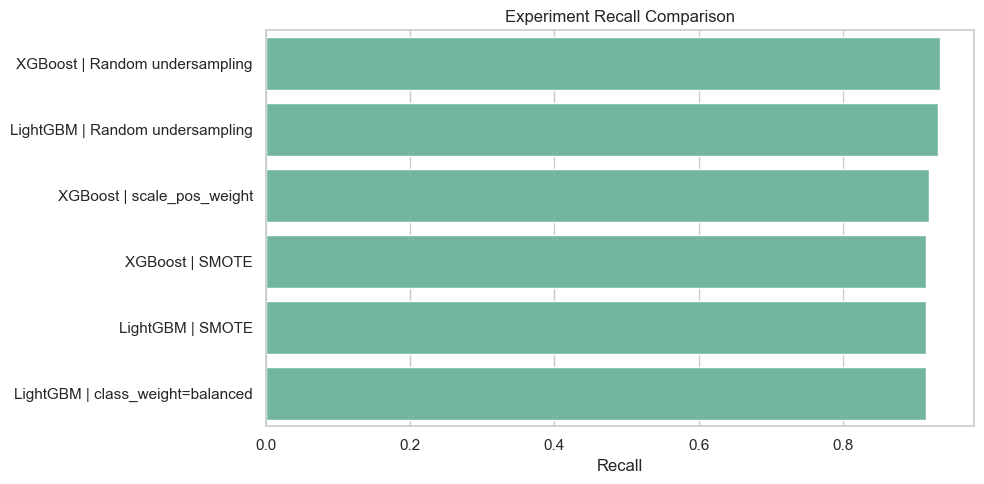

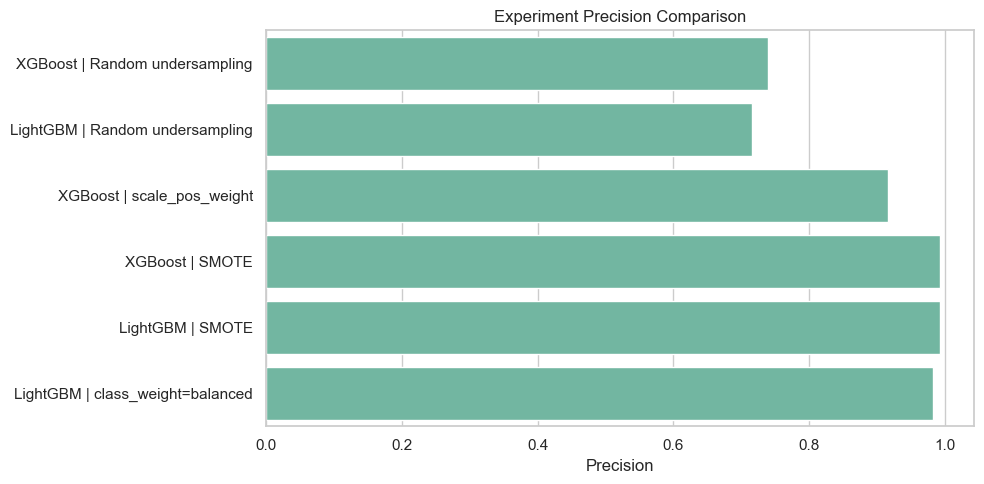

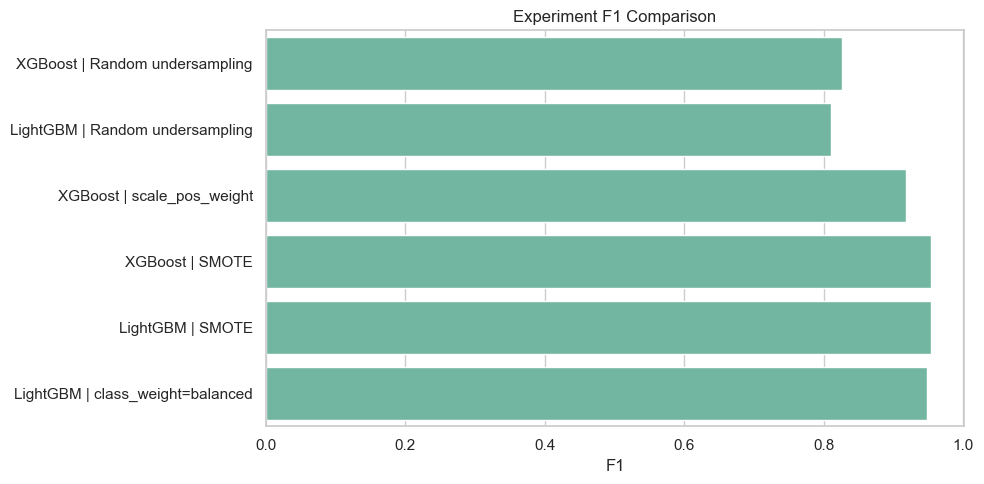

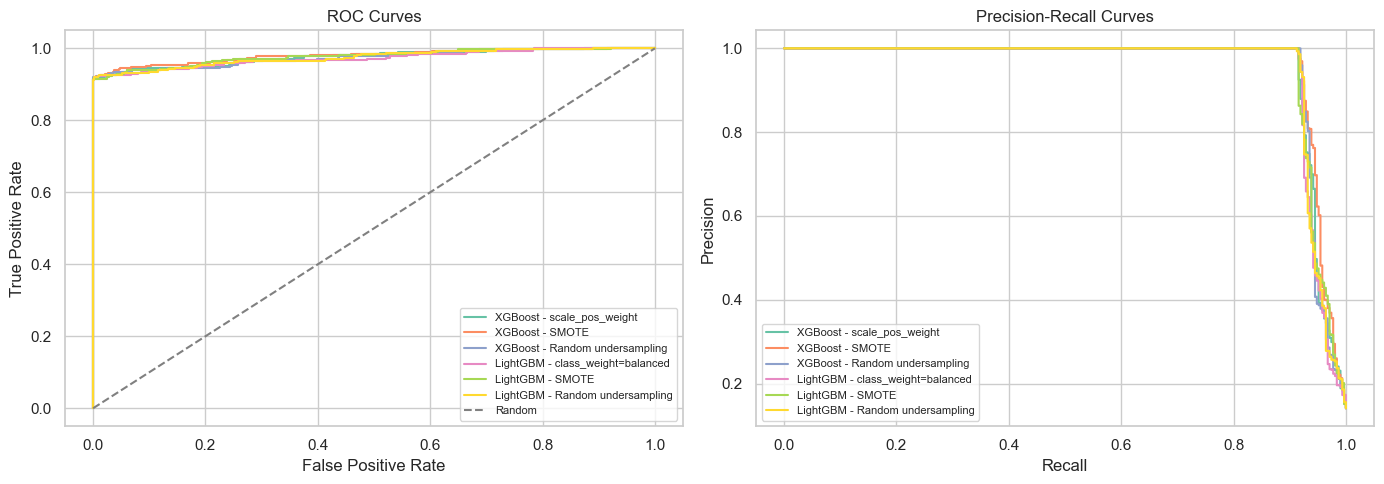

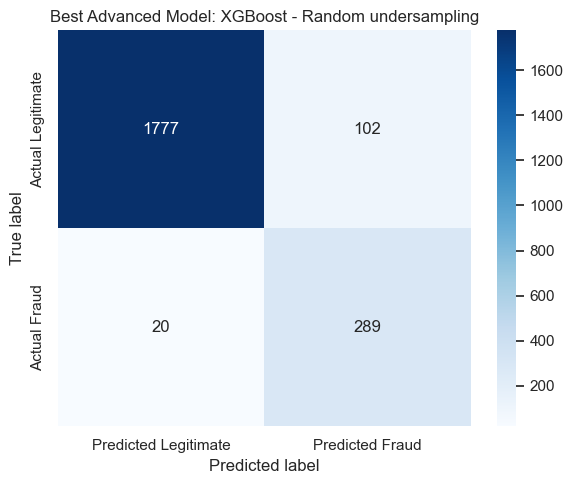

In [13]:
metric_plots = [
    ("recall", "Experiment Recall Comparison", "experiment_recall_comparison.png"),
    ("precision", "Experiment Precision Comparison", "experiment_precision_comparison.png"),
    ("f1", "Experiment F1 Comparison", "experiment_f1_comparison.png"),
]

plot_df = experiment_log.copy()
plot_df["experiment"] = plot_df["model"] + " | " + plot_df["technique"]

for metric, title, filename in metric_plots:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_df, x=metric, y="experiment", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_roc_pr_curves(completed_models)

best_row = experiment_log.iloc[0]
best_label = f"{best_row['model']} - {best_row['technique']}"
best_model = completed_models[best_label]["pipeline"]
best_pred = best_model.predict(X_test)
best_cm = confusion_matrix(y_test, best_pred, labels=[0, 1])
plot_confusion_matrix(best_cm, f"Best Advanced Model: {best_label}", "best_advanced_confusion_matrix.png")


Although XGBoost with Random Undersampling achieved the highest recall (93.5%), it generated 102 false positives, substantially increasing the number of legitimate transactions incorrectly classified as fraudulent. In contrast, XGBoost with SMOTE achieved a slightly lower recall (91.6%) but reduced false positives to only two while maintaining the highest precision (99.3%) and F1-score (95.3%). Since the project objective is to improve recall without excessive false positives, XGBoost trained with SMOTE represents the most balanced and practical solution for the NovaPay fraud detection system.

Final verdict
Highest Recall: XGBoost + Random Undersampling.
Best overall model for the project objective: XGBoost + SMOTE.

## 13. Baseline vs Advanced Recall Comparison

This section directly answers the assessment question by comparing the best Day 5 baseline recall with the best Day 6 advanced recall. Recall is the headline metric because the business cost of missing fraud is high.

The comparison is still interpreted alongside precision and F1 from the experiment log, because a model that catches more fraud may also create more false alerts.


In [14]:
best_advanced_recall = float(best_row["recall"])

if baseline_metrics is not None and not baseline_metrics.empty:
    recall_column = next((col for col in baseline_metrics.columns if col.lower() == "recall"), None)
    model_column = next((col for col in baseline_metrics.columns if col.lower() in ["model", "model_name", "classifier"]), None)

    if recall_column is not None:
        best_baseline = baseline_metrics.sort_values(recall_column, ascending=False).iloc[0]
        baseline_model_name = best_baseline[model_column] if model_column is not None else "Best Day 5 baseline"
        baseline_recall = float(best_baseline[recall_column])
        baseline_vs_advanced = pd.DataFrame(
            [
                {
                    "baseline_model": baseline_model_name,
                    "baseline_recall": baseline_recall,
                    "best_advanced_model": best_label,
                    "advanced_recall": best_advanced_recall,
                    "recall_improvement": best_advanced_recall - baseline_recall,
                }
            ]
        )
    else:
        baseline_vs_advanced = pd.DataFrame(
            [
                {
                    "baseline_model": "Baseline metrics file found, but no recall column was detected",
                    "baseline_recall": np.nan,
                    "best_advanced_model": best_label,
                    "advanced_recall": best_advanced_recall,
                    "recall_improvement": np.nan,
                }
            ]
        )
else:
    baseline_vs_advanced = pd.DataFrame(
        [
            {
                "baseline_model": "Day 5 baseline metrics unavailable",
                "baseline_recall": np.nan,
                "best_advanced_model": best_label,
                "advanced_recall": best_advanced_recall,
                "recall_improvement": np.nan,
            }
        ]
    )

baseline_vs_advanced.to_csv(ARTIFACTS_DIR / "baseline_vs_advanced_recall.csv", index=False)
display(baseline_vs_advanced)


,baseline_model,baseline_recall,best_advanced_model,advanced_recall,recall_improvement
0,Logistic Regression,0.938511,XGBoost - Random undersampling,0.935275,-0.003236


## 14. Threshold Tuning for Best Advanced Model

After training, the best model produces fraud probabilities. Converting those probabilities into fraud/not-fraud labels requires a decision threshold. The default threshold of 0.50 is not automatically best for imbalanced fraud detection.

This section tests multiple thresholds and records accuracy, precision, recall, F1, true negatives, false positives, false negatives, and true positives. This makes the operating trade-off explicit: lowering the threshold can catch more fraud, but it may also increase false positives.


,threshold,precision,recall,f1,false_positives,false_negatives
0,0.05,0.222790,0.987055,0.363528,1064,4
1,0.10,0.293425,0.967638,0.450301,720,10
2,0.15,0.361754,0.961165,0.525664,524,12
3,0.20,0.418938,0.944984,0.580517,405,17
4,0.25,0.484245,0.944984,0.640351,311,17
5,0.30,0.537753,0.944984,0.685446,251,17
6,0.35,0.584677,0.938511,0.720497,206,19
7,0.40,0.647321,0.938511,0.766182,158,19
8,0.45,0.687204,0.938511,0.793434,132,19
9,0.50,0.739130,0.935275,0.825714,102,20


Recommended threshold:


,threshold,precision,recall,f1,false_positives,false_negatives
18,0.95,1.0,0.915858,0.956081,0.0,26.0


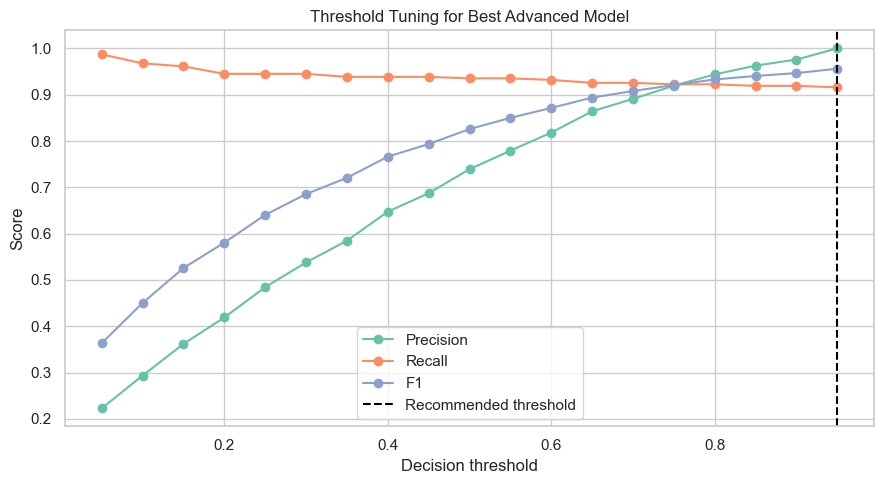

In [15]:
threshold_df, recommended_threshold = threshold_tuning(best_model, X_test, y_test)
threshold_df.to_csv(ARTIFACTS_DIR / "best_advanced_threshold_analysis.csv", index=False)

display(threshold_df)
print("Recommended threshold:")
display(recommended_threshold.to_frame().T)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
ax.axvline(recommended_threshold["threshold"], linestyle="--", color="black", label="Recommended threshold")
ax.set_title("Threshold Tuning for Best Advanced Model")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_advanced_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()


## 15. Save Best Model and Summary Artifacts

The best advanced pipeline is saved so it can be reused without retraining. The summary JSON captures the main result, the recommended threshold, and the artifact paths. A short experiment-results summary and requirement checklist are also saved for quick reviewer access.


In [16]:
joblib.dump(best_model, MODELS_DIR / "best_advanced_model.joblib")

summary = {
    "best_model": str(best_row["model"]),
    "best_technique": str(best_row["technique"]),
    "best_recall": float(best_row["recall"]),
    "best_precision": float(best_row["precision"]),
    "best_f1": float(best_row["f1"]),
    "best_roc_auc": float(best_row["roc_auc"]) if pd.notna(best_row["roc_auc"]) else None,
    "recommended_threshold": float(recommended_threshold["threshold"]),
    "number_of_experiments_completed": int(len(experiment_log)),
    "experiment_log_path": str(ARTIFACTS_DIR / "advanced_experiment_log.csv"),
    "threshold_analysis_path": str(ARTIFACTS_DIR / "best_advanced_threshold_analysis.csv"),
    "model_path": str(MODELS_DIR / "best_advanced_model.joblib"),
}

with open(ARTIFACTS_DIR / "day6_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

roc_auc_text = f"{summary['best_roc_auc']:.3f}" if summary["best_roc_auc"] is not None else "not available"

summary_markdown = f"""# Experiment Results Summary

The best Day 6 advanced experiment was **{summary['best_model']}** with **{summary['best_technique']}**. It achieved recall of **{summary['best_recall']:.3f}**, precision of **{summary['best_precision']:.3f}**, F1 of **{summary['best_f1']:.3f}**, and ROC-AUC of **{roc_auc_text}** on the untouched time-based test set.

This result is selected primarily by recall because fraud detection should minimise missed fraud cases. Precision and F1 are still reviewed so the selected model does not create an unreasonable number of false positives. The recommended operating threshold is **{summary['recommended_threshold']:.2f}**.
"""

(ARTIFACTS_DIR / "experiment_results_summary.md").write_text(summary_markdown, encoding="utf-8")
display(Markdown(summary_markdown))

checklist_rows = [
    {"Requirement": "XGBoost trained/tuned", "Status": "Yes" if XGBOOST_AVAILABLE and any(experiment_log["model"].eq("XGBoost")) else "Skipped - xgboost package unavailable"},
    {"Requirement": "LightGBM trained/tuned", "Status": "Yes" if LIGHTGBM_AVAILABLE and any(experiment_log["model"].eq("LightGBM")) else "Skipped - lightgbm package unavailable"},
    {"Requirement": "SMOTE tested", "Status": "Yes" if IMBLEARN_AVAILABLE and any(experiment_log["technique"].eq("SMOTE")) else "Skipped - imbalanced-learn package unavailable"},
    {"Requirement": "Undersampling tested", "Status": "Yes" if IMBLEARN_AVAILABLE and any(experiment_log["technique"].eq("Random undersampling")) else "Skipped - imbalanced-learn package unavailable"},
    {"Requirement": "Class weighting tested", "Status": "Yes"},
    {"Requirement": "Experiment log created", "Status": "Yes"},
    {"Requirement": "Baseline vs advanced recall compared", "Status": "Yes"},
    {"Requirement": "Reflection included", "Status": "Yes"},
]
requirement_checklist = pd.DataFrame(checklist_rows)
requirement_checklist.to_csv(ARTIFACTS_DIR / "requirement_checklist.csv", index=False)
display(requirement_checklist)


{
  "best_model": "XGBoost",
  "best_technique": "Random undersampling",
  "best_recall": 0.9352750809061489,
  "best_precision": 0.7391304347826086,
  "best_f1": 0.8257142857142857,
  "best_roc_auc": 0.9740480287145783,
  "recommended_threshold": 0.95,
  "number_of_experiments_completed": 6,
  "experiment_log_path": "C:\\Users\\sadeq\\reports\\artifacts\\day6\\advanced_experiment_log.csv",
  "threshold_analysis_path": "C:\\Users\\sadeq\\reports\\artifacts\\day6\\best_advanced_threshold_analysis.csv",
  "model_path": "C:\\Users\\sadeq\\models\\day6\\best_advanced_model.joblib"
}


# Experiment Results Summary

The best Day 6 advanced experiment was **XGBoost** with **Random undersampling**. It achieved recall of **0.935**, precision of **0.739**, F1 of **0.826**, and ROC-AUC of **0.974** on the untouched time-based test set.

This result is selected primarily by recall because fraud detection should minimise missed fraud cases. Precision and F1 are still reviewed so the selected model does not create an unreasonable number of false positives. The recommended operating threshold is **0.95**.


,Requirement,Status
0,XGBoost trained/tuned,Yes
1,LightGBM trained/tuned,Yes
2,SMOTE tested,Yes
3,Undersampling tested,Yes
4,Class weighting tested,Yes
5,Experiment log created,Yes
6,Baseline vs advanced recall compared,Yes
7,Reflection included,Yes


## 16. Reflection: Fraud Prevalence Across Time

Fraud prevalence can vary across time because attacker behaviour changes, seasonal spending patterns shift, new products are launched, and fraud controls become stronger or weaker. A model trained during one fraud pattern may perform less reliably when the fraud rate or fraud type changes later.

This affects performance stability in several ways. Recall may drop if new fraud patterns appear that were rare or absent in training. Precision may also fall if legitimate behaviour changes and begins to resemble older fraud patterns. Average precision is especially sensitive to prevalence because the proportion of positive cases affects the precision-recall curve.

The time-based split helps reveal this risk because the model is evaluated on a later period rather than a randomly mixed sample. In production, NovaPay should monitor fraud prevalence, recall, precision, false-positive volume, and threshold performance over time. If these drift, the model may need recalibration, threshold adjustment, retraining, or updated features.


## 17. Requirement Checklist

The checklist is generated in the save step above so package-dependent items show either `Yes` or a clear skipped reason. This confirms that the notebook covers XGBoost, LightGBM when available, SMOTE, random undersampling, class weighting, experiment logging, baseline comparison, threshold tuning, and the fraud-prevalence reflection.


## 18. Experiment Results Summary

The generated summary above identifies the best-performing advanced experiment by the sorted experiment log, with recall prioritised and precision/F1 reviewed as safeguards. In plain terms, the best model is the one that catches the most fraud on the untouched future test period while still keeping false positives visible for business review.


## 19. Final Conclusion

This notebook satisfies the Day 6 advanced modelling requirements by training and comparing XGBoost and LightGBM experiments when packages are available, testing class weighting, SMOTE, and random undersampling, saving a structured experiment log, tuning the best model threshold, and comparing advanced recall against the Day 5 baseline where available.

The key modelling principle is that the test set stays untouched. All resampling happens only inside training pipelines, which keeps the reported results a realistic estimate of future fraud-detection performance.


In [1]:
from pathlib import Path

MODEL_DIR = Path("models/day6")

print(MODEL_DIR.resolve())
print(list(MODEL_DIR.glob("*")))

C:\Users\sadeq\models\day6
[WindowsPath('models/day6/best_advanced_model.joblib')]
